# 01｜认识数据、数据集与张量

本页不会训练模型。我们先把散点图、数学符号和 PyTorch 中的 `Tensor` 对齐。

完成本页后，你应该能回答：

1. 一个样本、一个特征和一个标签分别是什么？
2. 为什么二维分类数据的 `X.shape` 是 `[样本数, 2]`？
3. `Tensor` 的 `shape`、`dtype` 和 `device` 分别说明什么？
4. 训练集与测试集为什么要分开？

In [1]:
%matplotlib inline
from pathlib import Path
import sys

LAB_DIR = Path.cwd()
if not (LAB_DIR / "mlp_lab").is_dir():
    LAB_DIR = (LAB_DIR / "01_mlp_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

import torch
import matplotlib.pyplot as plt
from mlp_lab import make_dataset, show_datasets
from data_and_task import plot_data_explanation, plot_task_flow

## 1｜把散点图写成数学数据集

监督学习数据集可以写成：

$$
\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{N}
$$

- $N$：样本总数；
- $\mathbf{x}_i$：第 $i$ 个样本的特征；
- $y_i$：第 $i$ 个样本的类别标签。

本实验中的一个点有横、纵两个坐标，因此：

$$
\mathbf{x}_i=
\begin{bmatrix}
x_{i1}\\
x_{i2}
\end{bmatrix}
\in\mathbb{R}^{2},
\qquad
y_i\in\{0,1,\ldots,C-1\}
$$

把全部样本按行堆叠，就得到特征矩阵和标签向量：

$$
X=
\begin{bmatrix}
\mathbf{x}_1^\top\\
\mathbf{x}_2^\top\\
\vdots\\
\mathbf{x}_N^\top
\end{bmatrix}
\in\mathbb{R}^{N\times 2},
\qquad
\mathbf{y}=
\begin{bmatrix}
y_1&y_2&\cdots&y_N
\end{bmatrix}^{\top}
\in\{0,\ldots,C-1\}^{N}
$$

**数学中的一行，就是图中的一个点，也是代码中的一个样本。**

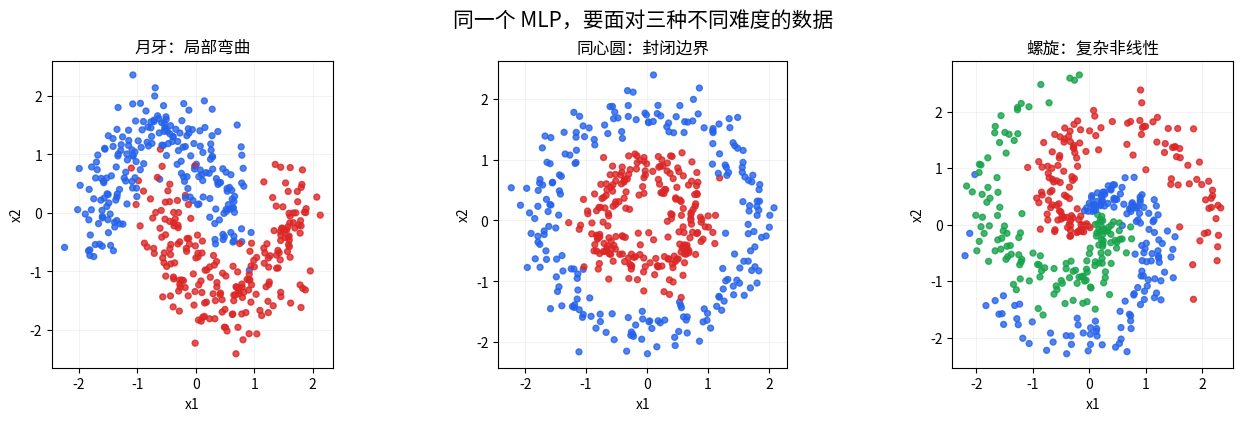

In [2]:
datasets_figure = show_datasets(seed=42, n_samples=450)

## 2｜什么是 Tensor？

Tensor（张量）可以理解为“带有统一数据类型、形状和设备信息的多维数组”。矩阵是二维 Tensor，但 Tensor 不只包含矩阵。

| 数学对象 | 维数 | PyTorch shape | 例子 |
|---|---:|---|---|
| 标量 scalar | 0 | `[]` | 一个 Loss |
| 向量 vector | 1 | `[d]` | 一个样本的 $d$ 个特征 |
| 矩阵 matrix | 2 | `[N, d]` | $N$ 个样本组成的数据集 |
| 更高维 Tensor | 3 或更多 | `[B, C, H, W]` 等 | 一批图像或序列 |

查看 Tensor 时，先看四件事：

- `ndim`：有几条轴；
- `shape`：每条轴有多长；
- `dtype`：数字采用什么类型；
- `device`：数据位于 CPU 还是 GPU。

In [3]:
examples = {
    "标量 Loss": torch.tensor(0.75),
    "一个二维样本": torch.tensor([1.2, -0.4]),
    "三个二维样本": torch.tensor([[1.2, -0.4], [0.3, 0.8], [-0.7, 0.1]]),
    "四张灰度图": torch.zeros(4, 1, 8, 8),
}

for name, tensor in examples.items():
    print(f"{name:12s} ndim={tensor.ndim}  shape={tuple(tensor.shape)}  "
          f"dtype={tensor.dtype}  device={tensor.device}")

标量 Loss      ndim=0  shape=()  dtype=torch.float32  device=cpu
一个二维样本       ndim=1  shape=(2,)  dtype=torch.float32  device=cpu
三个二维样本       ndim=2  shape=(3, 2)  dtype=torch.float32  device=cpu
四张灰度图        ndim=4  shape=(4, 1, 8, 8)  dtype=torch.float32  device=cpu


## 3｜代码中的 $X$ 和 $y$

下面取出螺旋数据。`X[i]` 和 `y[i]` 必须配对：前者是第 $i$ 个样本的两个特征，后者是它的类别。

训练集的数学写法是：

$$
X_{\mathrm{train}}\in\mathbb{R}^{N_{\mathrm{train}}\times 2},
\qquad
y_{\mathrm{train}}\in\{0,1,2\}^{N_{\mathrm{train}}}
$$

In [4]:
data = make_dataset("spiral", n_samples=450, noise=0.45, seed=42)

print("训练输入 X：", tuple(data.x_train.shape), data.x_train.dtype)
print("训练标签 y：", tuple(data.y_train.shape), data.y_train.dtype)
print("测试输入 X：", tuple(data.x_test.shape))
print("类别数量：", data.n_classes)
print("\n第 0 个样本：")
print("  X[0] =", data.x_train[0].tolist())
print("  y[0] =", data.y_train[0].item())

训练输入 X： (337, 2) torch.float32
训练标签 y： (337,) torch.int64
测试输入 X： (113, 2)
类别数量： 3

第 0 个样本：
  X[0] = [-1.79445481300354, 1.182649850845337]
  y[0] = 2


## 4｜为什么要划分和标准化？

训练集用于更新模型参数，测试集只用于检查模型面对未参与训练的数据时表现如何。

标准化时，第 $j$ 个特征只使用训练集计算：

$$
\mu_j=\frac{1}{N_{\mathrm{train}}}\sum_{i=1}^{N_{\mathrm{train}}}x_{ij},
\qquad
\sigma_j=\sqrt{\frac{1}{N_{\mathrm{train}}}\sum_{i=1}^{N_{\mathrm{train}}}(x_{ij}-\mu_j)^2}
$$

然后对训练集和测试集应用同一转换：

$$
\widetilde{x}_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j}
$$

如果先用测试集计算 $\mu$ 或 $\sigma$，相当于提前看到了测试信息。

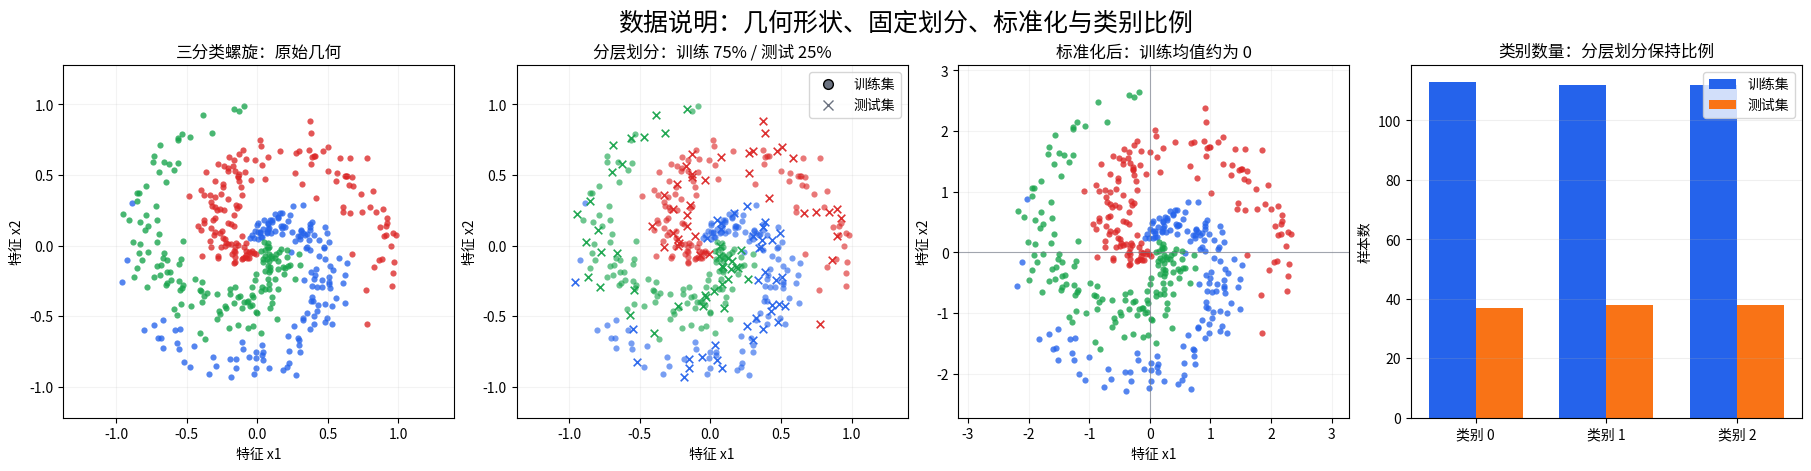

训练集标准化后均值： [0.0, -0.0]
训练集标准化后标准差： [1.0, 1.0]


In [5]:
plot_data_explanation([data])
plt.show()

print("训练集标准化后均值：", data.x_train.mean(dim=0).numpy().round(4).tolist())
print("训练集标准化后标准差：", data.x_train.std(dim=0, unbiased=False).numpy().round(4).tolist())

## 5｜从 shape 推出 MLP 的输入输出

假设一个 Batch 中有 $B$ 个样本，第一层有 $H$ 个神经元：

$$
X_{B}\in\mathbb{R}^{B\times 2},\quad
W^{(1)}\in\mathbb{R}^{2\times H},\quad
b^{(1)}\in\mathbb{R}^{H}
$$

第一层计算：

$$
Z^{(1)}=X_BW^{(1)}+b^{(1)}\in\mathbb{R}^{B\times H}
$$

如果共有 $C$ 类，模型最终输出：

$$
\mathrm{logits}\in\mathbb{R}^{B\times C}
$$

例如 $B=64$、$H=32$、$C=3$ 时，输入为 `[64, 2]`，隐藏表示为 `[64, 32]`，输出为 `[64, 3]`。

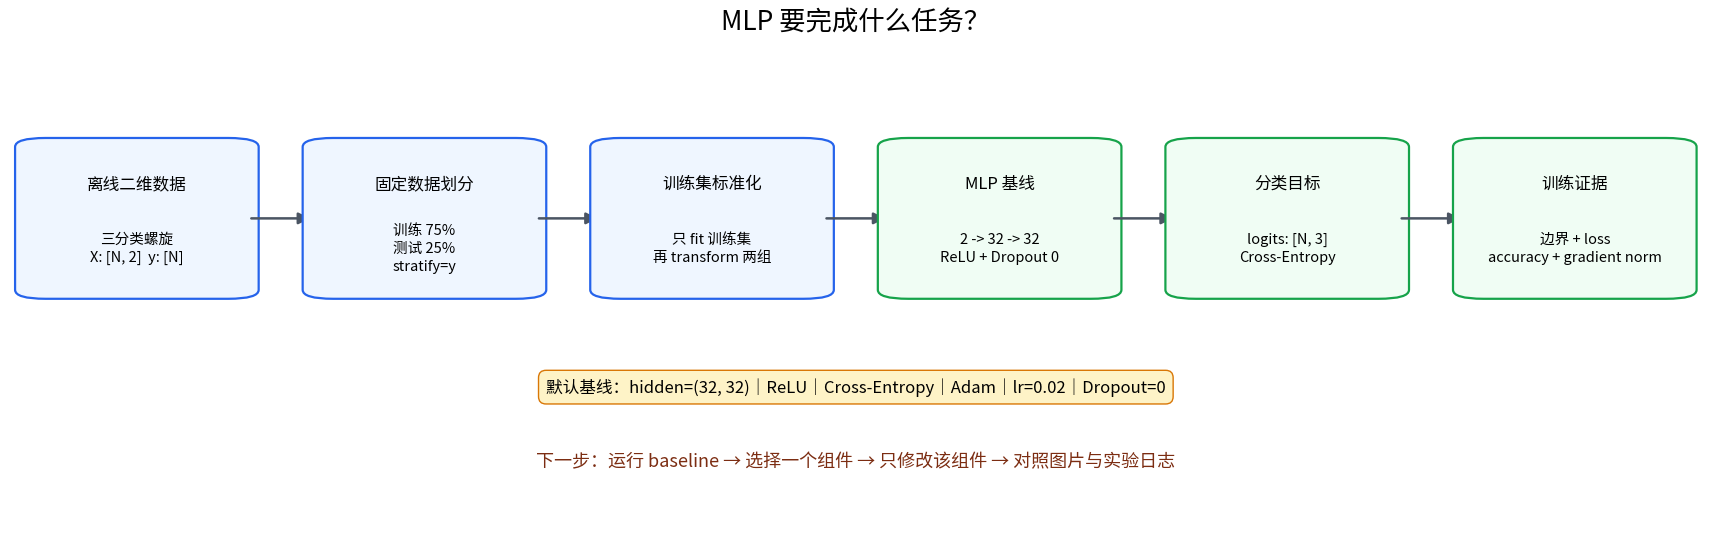

In [6]:
plot_task_flow("spiral", data.n_classes)
plt.show()

## 本页小结

- Dataset 是样本—标签对的集合；
- Tensor 是模型实际接收和计算的数据容器；
- `shape` 的第一维通常表示样本数，第二维表示特征数；
- `X[i]` 必须和 `y[i]` 对应；
- 测试集不参与模型更新，标准化参数也只能从训练集估计。

下一页将解释训练时最常出现的几个词：`Batch`、`Epoch`、`Iteration`、`Learning rate`、`Loss` 和梯度。

## 完成本页后：释放资源并结束内核

运行下面的最后一个单元格。它会依次清空变量、关闭图片、释放未使用的 CUDA 缓存，并向 Jupyter 内核发送正常关机请求。

运行后，VS Code 可能显示“内核已停止”“请选择内核”或暂时断开连接，这是正常现象，表示当前 Notebook 的 Python 进程已经结束。再次实验时，重新选择 Python 内核即可。

In [7]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()

# 先释放当前进程中未使用的 CUDA 缓存。
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("清理完成，正在结束当前 Notebook 的 Python 内核……")

# 正常关闭当前 Jupyter 内核；再次运行时需要重新选择内核。
get_ipython().kernel.do_shutdown(restart=False)


清理完成，正在结束当前 Notebook 的 Python 内核……

{'status': 'ok', 'restart': False}